# Experiences complementaires

Ce notebook vient en plus des trois autres. Les notebooks 01, 02 et 03 montrent que les
methodes marchent. Ici j'essaie d'aller un cran plus loin et de tester quelques hypotheses.
Trois questions :

1. est-ce que mes resultats bougent beaucoup si je change juste la graine aleatoire ? (autrement dit : est-ce que les ecarts que je vois sont reels ou juste du hasard)
2. est-ce que le pre-entrainement aide encore quand on a tres peu de labels ?
3. est-ce que le pre-entrainement sert vraiment, compare a un encodeur qu'on n'a jamais entraine ?

Le notebook est autonome : je recopie le modele et les fonctions du notebook 02 pour qu'il
tourne tout seul. Ca prend quelques minutes sur CPU.

In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


# meme decoupage que le notebook 02 : 60% train, 20% val, 20% test
data = load_breast_cancer()
X, y = data.data, data.target
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=123, stratify=y_trainval)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Xtr_t = torch.from_numpy(X_train).float()
Xte_t = torch.from_numpy(X_test).float()
yte_t = torch.from_numpy(y_test).long()

# le pre-entrainement voit tout le train mais sans les labels (c'est ca l'auto-supervise)
pretrain_loader = DataLoader(TensorDataset(Xtr_t), batch_size=64, shuffle=True)
# le test sert juste a evaluer, jamais a entrainer
test_loader = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=64, shuffle=False)


def make_clf_loader(X_arr, y_arr):
    # petit utilitaire : fabrique un loader d'entrainement supervise a partir de numpy.
    # utile quand on ne garde qu'une partie des labels (etude 2)
    xb = torch.from_numpy(np.asarray(X_arr)).float()
    yb = torch.from_numpy(np.asarray(y_arr)).long()
    return DataLoader(TensorDataset(xb, yb), batch_size=64, shuffle=True)

## Le modele et les fonctions de base

Rien de neuf ici, c'est repris du notebook 02 : le meme auto-encodeur, plus trois fonctions
(pre-entrainement, entrainement de la tete de classif, evaluation sur le test).

In [2]:
# auto-encodeur : encodeur 30 -> 14 -> 6 -> latent, decodeur latent -> 6 -> 14 -> 30
class Encodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 14), nn.LeakyReLU(),
            nn.Linear(14, 6), nn.LeakyReLU(),
            nn.Linear(6, latent_dim))
    def forward(self, x):
        return self.net(x)

class Decodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 6), nn.LeakyReLU(),
            nn.Linear(6, 14), nn.LeakyReLU(),
            nn.Linear(14, 30))
    def forward(self, z):
        return self.net(z)

class AutoEncodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encodeur = Encodeur(latent_dim)
        self.decodeur = Decodeur(latent_dim)
    def forward(self, x):
        return self.decodeur(self.encodeur(x))

class Classifieur(nn.Module):
    # encodeur + petite tete. freeze=True => encodeur gele (linear probing),
    # freeze=False => tout s'entraine (full fine-tuning)
    def __init__(self, encodeur, latent_dim, freeze):
        super().__init__()
        self.encodeur = encodeur
        if freeze:
            for p in self.encodeur.parameters():
                p.requires_grad = False
        self.tete = nn.Sequential(
            nn.Linear(latent_dim, 8), nn.LeakyReLU(),
            nn.Linear(8, 2))
    def forward(self, x):
        return self.tete(self.encodeur(x))


def pretrain(latent_dim, epochs=80):
    # pre-entrainement non supervise : l'AE apprend juste a reconstruire les donnees
    ae = AutoEncodeur(latent_dim)
    opt = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    for _ in range(epochs):
        ae.train()
        for (xb,) in pretrain_loader:
            opt.zero_grad()
            loss_fn(ae(xb), xb).backward()
            opt.step()
    return ae

def train_clf(model, loader, epochs=80):
    # on n'entraine que les parametres non geles (pour le probing, ca fait juste la tete)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(set_to_none=True)
            loss_fn(model(xb), yb).backward()
            opt.step()
    return model

def test_scores(model):
    # renvoie le F1 macro et le ROC-AUC sur le jeu de test
    model.eval()
    yt, yp, pp = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            pp.extend(torch.softmax(logits, dim=1)[:, 1].numpy())
            yp.extend(logits.argmax(dim=1).numpy())
            yt.extend(yb.numpy())
    yt, yp, pp = np.array(yt), np.array(yp), np.array(pp)
    return f1_score(yt, yp, average="macro"), roc_auc_score(yt, pp)

## Etude 1 : est-ce que les scores sont stables ?

Le probleme d'un seul run, c'est qu'on ne sait pas si le chiffre obtenu est representatif ou
juste un coup de chance lie a l'initialisation aleatoire. Ici je relance tout le pipeline
(pre-entrainement + probing + full fine-tuning) avec 5 graines differentes, et je regarde la
moyenne et l'ecart-type. Si l'ecart-type est petit, mes conclusions tiennent. S'il est gros,
c'est qu'il faut se mefier des petites differences.

probing AUC  : 0.988 +/- 0.008
probing F1   : 0.938 +/- 0.016
full-ft AUC  : 0.995 +/- 0.008
full-ft F1   : 0.983 +/- 0.004


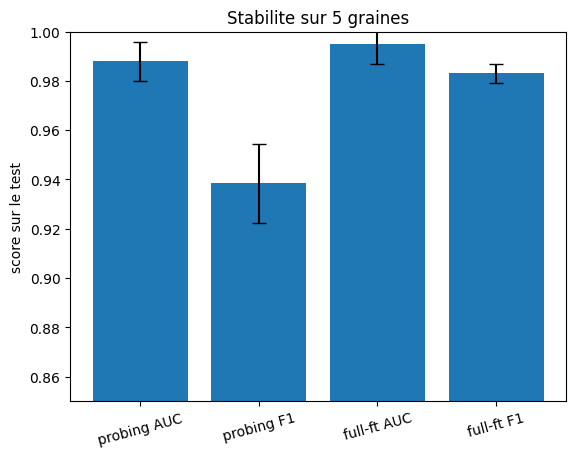

In [4]:
def run_once(seed, latent_dim=2):
    # un pipeline complet pour une graine donnee, renvoie les 4 scores
    set_seed(seed)
    ae = pretrain(latent_dim)   # meme AE de depart pour les deux regimes

    # linear probing : encodeur gele, on entraine juste la tete
    set_seed(seed)
    probe = Classifieur(copy.deepcopy(ae.encodeur), latent_dim, freeze=True)
    train_clf(probe, make_clf_loader(X_train, y_train))
    pf1, pauc = test_scores(probe)

    # full fine-tuning : memes poids de depart, mais rien n'est gele
    set_seed(seed)
    ft = Classifieur(copy.deepcopy(ae.encodeur), latent_dim, freeze=False)
    train_clf(ft, make_clf_loader(X_train, y_train))
    ff1, fauc = test_scores(ft)
    return [pauc, pf1, fauc, ff1]


SEEDS = [0, 1, 2, 3, 4]
arr = np.array([run_once(s) for s in SEEDS])   

noms = ["probing AUC", "probing F1", "full-ft AUC", "full-ft F1"]
for i, nom in enumerate(noms):
    print(f"{nom:12s} : {arr[:, i].mean():.3f} +/- {arr[:, i].std():.3f}")

plt.bar(range(4), arr.mean(axis=0), yerr=arr.std(axis=0), capsize=5)
plt.xticks(range(4), noms, rotation=15)
plt.ylim(0.85, 1.0)
plt.ylabel("score sur le test")
plt.title("Stabilite sur 5 graines")
plt.savefig("figures/seeds_stability.png", dpi=130, bbox_inches="tight")
plt.show()

### Ce qu'on observe

Les ecarts-types sont petits (autour de 0.008 sur l'AUC), donc les scores bougent peu d'une
graine a l'autre. Les conclusions des notebooks precedents ne tiennent donc pas a un coup de
chance. Le full fine-tuning reste au-dessus du probing sur les deux metriques, de maniere
reguliere.

## Etude 2 : est-ce que le pre-entrainement aide quand on a peu de labels ?

C'est la que le pre-entrainement devient vraiment interessant. L'idee : les labels coutent
cher (il faut un medecin pour annoter), mais les donnees brutes non. Donc on pre-entraine
l'encodeur sur TOUT le train sans labels (gratuit), et on n'utilise qu'une petite fraction des
labels pour entrainer la tete de classif. On compare a une regression logistique entrainee sur
la meme petite fraction. Si le pre-entrainement sert a quelque chose, il devrait mieux resister
quand il reste peu de labels.

labels   5%  ->  SSL+probing AUC 0.886  |  logreg AUC 0.987
labels  10%  ->  SSL+probing AUC 0.941  |  logreg AUC 0.989
labels  25%  ->  SSL+probing AUC 0.976  |  logreg AUC 0.992
labels  50%  ->  SSL+probing AUC 0.984  |  logreg AUC 0.990
labels 100%  ->  SSL+probing AUC 0.988  |  logreg AUC 0.990


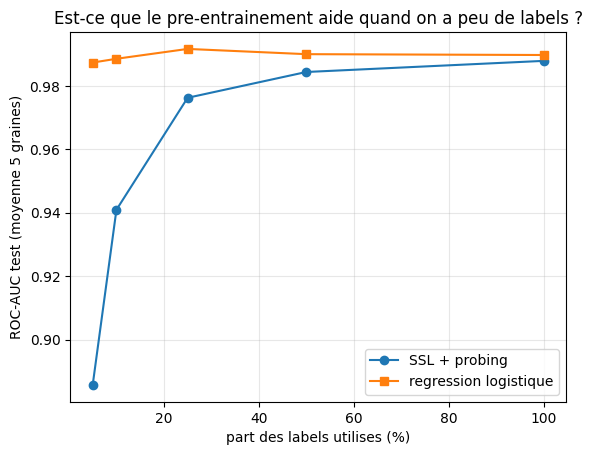

In [5]:
fracs = [0.05, 0.1, 0.25, 0.5, 1.0]

def subsample(frac, seed):
    # garde une fraction du train etiquete, en gardant les proportions des classes
    if frac >= 1.0:
        return X_train, y_train
    Xs, _, ys, _ = train_test_split(X_train, y_train, train_size=frac,
                                    stratify=y_train, random_state=seed)
    return Xs, ys

ssl_curve = {f: [] for f in fracs}
base_curve = {f: [] for f in fracs}

for seed in SEEDS:
    set_seed(seed)
    ae = pretrain(2)   # un seul pre-entrainement par graine, reutilise pour toutes les fractions
    for f in fracs:
        Xs, ys = subsample(f, seed)

        # cote pre-entrainement : encodeur gele + tete, entraines sur le sous-ensemble
        set_seed(seed)
        clf = Classifieur(copy.deepcopy(ae.encodeur), 2, freeze=True)
        train_clf(clf, make_clf_loader(Xs, ys))
        _, auc = test_scores(clf)
        ssl_curve[f].append(auc)

        # cote baseline : regression logistique sur exactement les memes donnees
        lr = LogisticRegression(max_iter=1000, class_weight="balanced")
        lr.fit(Xs, ys)
        base_curve[f].append(roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

ssl_mean = [np.mean(ssl_curve[f]) for f in fracs]
base_mean = [np.mean(base_curve[f]) for f in fracs]

for f, a, b in zip(fracs, ssl_mean, base_mean):
    print(f"labels {int(f*100):3d}%  ->  SSL+probing AUC {a:.3f}  |  logreg AUC {b:.3f}")

plt.plot([f * 100 for f in fracs], ssl_mean, "o-", label="SSL + probing")
plt.plot([f * 100 for f in fracs], base_mean, "s-", label="regression logistique")
plt.xlabel("part des labels utilises (%)")
plt.ylabel("ROC-AUC test (moyenne 5 graines)")
plt.title("Est-ce que le pre-entrainement aide quand on a peu de labels ?")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("figures/label_efficiency.png", dpi=130, bbox_inches="tight")
plt.show()

### Ce qu'on observe (le cas pre-entrainement vs regression logistique)

Resultat inattendu et interessant : ici la regression logistique bat le SSL+probing quand il y
a peu de labels (0.987 d'AUC avec seulement 5% des labels, contre 0.886 pour le probing). Le
SSL ne la rattrape qu'a 100% des labels.

Pourquoi ? Deux raisons. D'abord les donnees sont deja presque lineairement separables dans
l'espace des 30 variables brutes, donc une regression logistique s'en sort tres bien meme avec
tres peu d'exemples. Ensuite l'encodeur compresse en 2 dimensions seulement : il jette beaucoup
d'information, et la petite tete a donc moins de matiere pour decider. Autrement dit, sur ce
dataset facile, le pre-entrainement ne donne pas l'avantage qu'on lui prete souvent en faible
regime de labels. Cet avantage apparaitrait plutot sur des donnees ou les variables brutes ne
suffisent pas (images, signaux, variables tres correlees).

## Etude 3 : est-ce que le pre-entrainement sert vraiment ?

Question toute bete mais importante : et si le probing marchait aussi bien avec un encodeur
qu'on n'a jamais entraine ? Pour le savoir je compare deux cas, avec la meme tete et le meme
entrainement : un encodeur pre-entraine (gele) contre un encodeur aux poids aleatoires (gele
lui aussi, jamais pre-entraine). Si le pre-entraine gagne nettement, c'est que le
pre-entrainement apporte bien quelque chose. Je fais ca sur plusieurs graines, sinon l'ecart
pourrait juste etre du bruit.

encodeur pre-entraine : AUC 0.988 +/- 0.008
encodeur aleatoire    : AUC 0.686 +/- 0.201
ecart moyen           : +0.302


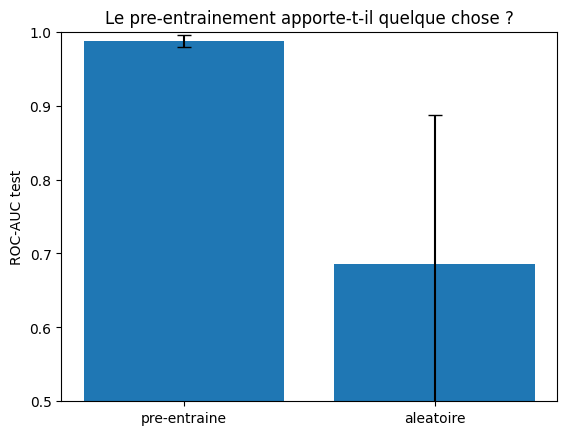

In [6]:
pre_scores, rnd_scores = [], []
for seed in SEEDS:
    set_seed(seed)
    ae = pretrain(2)

    #cas 1 : encodeur pre-entraine, gele
    set_seed(seed)
    clf_pre = Classifieur(copy.deepcopy(ae.encodeur), 2, freeze=True)
    train_clf(clf_pre, make_clf_loader(X_train, y_train))
    _, auc_pre = test_scores(clf_pre)
    pre_scores.append(auc_pre)

    #cas 2 : encodeur tout neuf (poids aleatoires), gele lui aussi
    set_seed(seed)
    enc_rnd = Encodeur(2)
    clf_rnd = Classifieur(enc_rnd, 2, freeze=True)
    train_clf(clf_rnd, make_clf_loader(X_train, y_train))
    _, auc_rnd = test_scores(clf_rnd)
    rnd_scores.append(auc_rnd)

pre_scores = np.array(pre_scores)
rnd_scores = np.array(rnd_scores)
print(f"encodeur pre-entraine : AUC {pre_scores.mean():.3f} +/- {pre_scores.std():.3f}")
print(f"encodeur aleatoire    : AUC {rnd_scores.mean():.3f} +/- {rnd_scores.std():.3f}")
print(f"ecart moyen           : {(pre_scores.mean() - rnd_scores.mean()):+.3f}")

plt.bar(["pre-entraine", "aleatoire"],
        [pre_scores.mean(), rnd_scores.mean()],
        yerr=[pre_scores.std(), rnd_scores.std()], capsize=5)
plt.ylim(0.5, 1.0)
plt.ylabel("ROC-AUC test")
plt.title("Le pre-entrainement apporte-t-il quelque chose ?")
plt.savefig("figures/ablation_pretrain.png", dpi=130, bbox_inches="tight")
plt.show()

### Ce qu'on observe

La difference est nette : encodeur pre-entraine a 0.988 d'AUC contre 0.686 pour un encodeur aux
poids aleatoires, ce dernier etant en plus tres instable (ecart-type 0.20). Donc a l'interieur
de l'approche "encodeur gele + tete", le pre-entrainement apporte clairement quelque chose.

A rapprocher de l'etude 2 : le pre-entrainement aide beaucoup par rapport a ne rien apprendre,
mais il ne suffit pas a battre une bonne baseline supervisee sur un dataset aussi simple.

## Ce que ces trois etudes montrent, au final

- Etude 1 : les resultats sont stables (petits ecarts-types), donc fiables.
- Etude 2 : sur ce dataset facile, le SSL+probing ne bat pas la regression logistique, surtout quand il y a peu de labels. Le goulot a 2 dimensions et la simplicite des donnees expliquent ca.
- Etude 3 : malgre tout, le pre-entrainement sert vraiment, il fait bien mieux qu'un encodeur non entraine.

La lecon que je retiens : le pre-entrainement aide par rapport a "rien", mais son interet reel
(faire mieux qu'une baseline supervisee avec peu de labels) se verrait sur des donnees plus
complexes, pas sur un cas aussi facile. C'est justement le genre de nuance qu'on ne voit qu'en
faisant l'experience soi-meme.